In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    
    # 构造复能量矩阵 (简化的写法，等价于你的 EI_gai)
    EI_gai = (E + 1j * eta) * np.eye(d, dtype=complex)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 G_00 和 G_01
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12
    
    # 3. Right-to-Left 扫掠：只记录向右连通的等效格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 格林函数 G_00 (原 G_DD_r[0:4, 0:4])
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出左上角右侧相邻的 4x4 非对角块 G_01 (原 G_DD_r[0:4, 4:8])
    # 根据 Dyson 方程，G_01 = G_00 * V_01 * gR_1
    #G_01 = G_00 @ V @ gR[1]

    # 返回你需要的结果 (去掉了庞大无用的 A_DD)
    return G_00, G_00, Sigma_R, Sigma_L

def bufeng(G_00):
    d = H_q.shape[0]
    yigeshu=np.trace(G_00)
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    
    # 构造松原频率复能量矩阵
    # 假设外部已经定义了 s0 = np.eye(2, dtype=complex)
    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 Matsubara G_00, G_01 和 G_10
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12

    # 特殊情况防错：如果 N=1，只有1个格点
    if N == 1:
        G_00 = np.linalg.inv(ALR - Sigma_L - Sigma_R)
        G_01 = np.zeros((d, d), dtype=complex)
        G_10 = np.zeros((d, d), dtype=complex)
        return G_00, G_01, G_10, Sigma_R, Sigma_L

    # 3. Right-to-Left 扫掠：只记录向右连通的等效松原格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 松原格林函数 G_00
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出右侧相邻的非对角块 G_01
    # 公式: G_{0,1} = G_{0,0} * V * gR_1
    G_01 = G_00 @ V @ gR[1]

    # 6. 算出下方相邻的非对角块 G_10
    # 公式: G_{1,0} = gR_1 * V^\dagger * G_{0,0}
    G_10 = gR[1] @ V.conj().T @ G_00

    # 返回优化后的结果 
    return G_00, G_01, G_10, Sigma_R, Sigma_L

def J_wn(G_01, G_10, T_12):
    d = T_12.shape[0]

    G_q_q1 = G_01
    G_q1_q = G_10

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        _, G_01, G_10, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_01, G_10, T_12))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onsite(hx,hz,saimanjiao,1,phi,t)
    H_q = H_onsite(mx,mz,zhongjian_saimanjiao,2,phi,t)
    H_r = H_onsite(hx,hz,saimanjiao,3,phi,t)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N)
    return Jphi

def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [13]:
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1  #/(2*np.pi)*(2*np.pi)
B=1  #/(2*np.pi)*(2*np.pi)

delta=0.35 #0.1
chaodaojiao=0
T_Tc=1e-4
Delta = delta#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

a=1
yw=100*a
xL=100*a

uN=0
#uS=0.03
uS=1
#Ey = 0.08/100
Ey=0.003/2

Ny = int(yw/a)
uN_set = []
for i in range(Ny):
    uN_set.append(uN - Ey * (i - Ny/2))
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS - Ey * (i - Ny/2))
uS_set=[]
for i in range(Ny):
    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_q= H_onstie(m,B,a   ,uN_set,0,0,    int(yw/a),4,    A)
T_21= H_hop(B,a,A,   int(yw/a),4)


H_r= H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
T_r= H_hop(B,a,A,   int(yw/a),4).conj().T

#print(H_q.shape)

Calculating Bands: 100%|██████████| 101/101 [00:04<00:00, 20.68it/s]


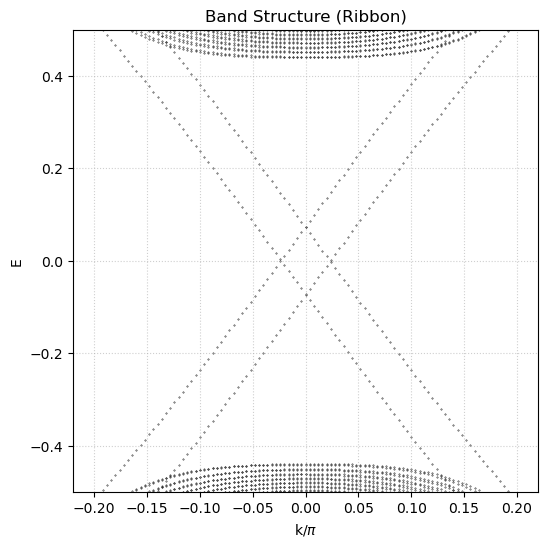

In [14]:
# 计算能带结构
ks = np.linspace(-0.2*np.pi, 0.2*np.pi, 101)
#ks = np.linspace(-2*np.pi, 2*np.pi, 101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies = []
# 使用 tqdm 显示进度条
for k in tqdm(ks, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals = np.linalg.eigvalsh(H_k)
    energies.append(evals)

energies = np.array(energies)

# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies.shape[1]):
    plt.scatter(ks/np.pi, energies[:, i], color='black', s=0.1)

plt.ylim(-0.5,0.5)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)
#plt.savefig('band_structure.png')

Calculating Bands: 100%|██████████| 101/101 [00:27<00:00,  3.64it/s]


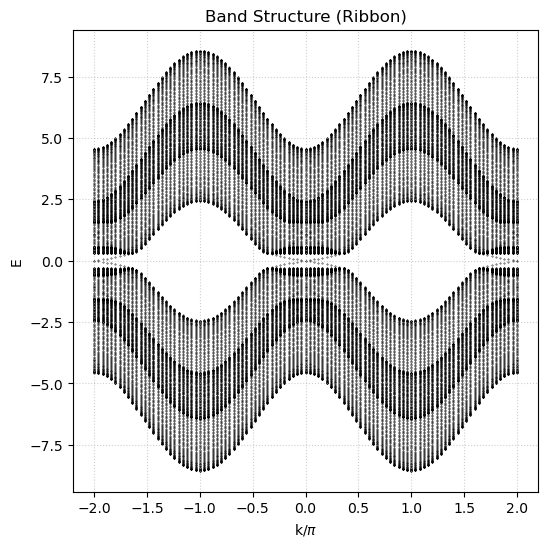

In [57]:
# 计算能带结构
ks1 = np.linspace(-2*np.pi, 2*np.pi, 101)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)


# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
#plt.xlim(-1,1)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

In [4]:
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1  #/(2*np.pi)*(2*np.pi)
B=1  #/(2*np.pi)*(2*np.pi)

delta=0.1
chaodaojiao=0
T_Tc=1e-4
Delta = delta#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

a=1
yw=11*a
xL=2*a

uN=0
uS=0.03
#uS=1
Ey = 0.0008
#Ey=0.003/100

Ny = int(yw/a)
uN_set = []
for i in range(Ny):
    uN_set.append(uN - Ey * (i - Ny/2))
uS_set=[]
for i in range(Ny):
    uS_set.append(uS - Ey * (i - Ny/2))
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_q= H_onstie(m,B,a   ,uN_set,0,0,    int(yw/a),4,    A)
T_21= H_hop(B,a,A,   int(yw/a),4)

H_l= H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
T_l= H_hop(B,a,A,   int(yw/a),4)

H_r= H_onstie(m,B,a   ,uS_set,Delta,0,    int(yw/a),4,    A)
T_r= H_hop(B,a,A,   int(yw/a),4).conj().T

T_LD=H_hop(B,a,A,   int(yw/a),4).conj().T
T_RD=H_hop(B,a,A,   int(yw/a),4)

#print(H_q.shape)

Calculating Bands: 100%|██████████| 301/301 [00:00<00:00, 12421.27it/s]


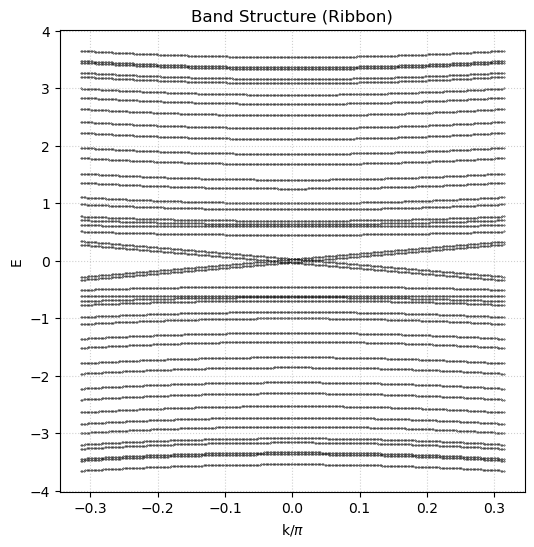

In [10]:
# 计算能带结构
ks1 = np.linspace(-0.1*np.pi, 0.1*np.pi, 301)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    # 使用 eigvalsh 专门针对 Hermitian 矩阵进行快速求解
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)


# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1, energies1[:, i], color='black', s=0.1)

#plt.ylim(-0.5,0.5)
#plt.xlim(-1,1)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

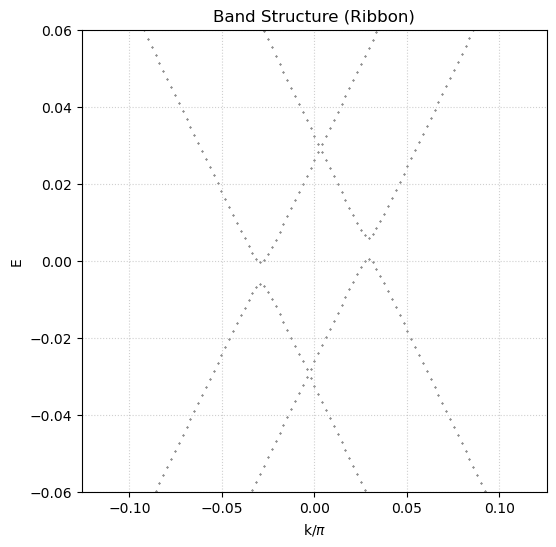

In [11]:
# 绘图：x 轴显示 kx，y 轴显示 E
plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1, energies1[:, i], color='black', s=0.1)

plt.ylim(-0.06,0.06)
plt.xlim(-0.04*np.pi,0.04*np.pi)
plt.xlabel(r'k/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

In [47]:
H_hop(B,a,A,   2,4)

array([[ 1.+0.j ,  0.-0.5j,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,
         0.+0.j ,  0.+0.j ],
       [ 0.-0.5j, -1.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,
         0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j , -1.+0.j , -0.-0.5j,  0.+0.j ,  0.+0.j ,
         0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j , -0.-0.5j,  1.+0.j ,  0.+0.j ,  0.+0.j ,
         0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  1.+0.j ,  0.-0.5j,
         0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.-0.5j, -1.+0.j ,
         0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,
        -1.+0.j , -0.-0.5j],
       [ 0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,  0.+0.j ,
        -0.-0.5j,  1.+0.j ]])

In [48]:
H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    2,4,    A)

NameError: name 'u_set' is not defined

In [ ]:
t_y(B,a,A)

array([[ 1. +0.j, -0.5+0.j,  0. +0.j,  0. +0.j],
       [ 0.5+0.j, -1. +0.j,  0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j, -1. +0.j,  0.5+0.j],
       [ 0. +0.j,  0. +0.j, -0.5+0.j,  1. +0.j]])

In [ ]:
t_x(B,a,A)

array([[ 1.+0.j ,  0.-0.5j,  0.+0.j ,  0.+0.j ],
       [ 0.-0.5j, -1.+0.j ,  0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j , -1.+0.j , -0.-0.5j],
       [ 0.+0.j ,  0.+0.j , -0.-0.5j,  1.+0.j ]])

In [ ]:
h_onstie(m,B,a   ,-0.003,Delta,chaodaojiao)

array([[-4.497+0.j,  0.   +0.j,  0.   +0.j,  0.35 -0.j],
       [ 0.   +0.j,  4.503-0.j, -0.35 +0.j,  0.   +0.j],
       [ 0.   -0.j, -0.35 -0.j,  4.497+0.j, -0.   +0.j],
       [ 0.35 +0.j,  0.   -0.j, -0.   +0.j, -4.503-0.j]])

In [ ]:
h_y(B,a,A)

array([[ 1. +0.j, -0.5+0.j],
       [ 0.5+0.j, -1. +0.j]])

In [ ]:
h_x(B,a,A)

array([[ 1.+0.j ,  0.-0.5j],
       [ 0.-0.5j, -1.+0.j ]])

In [ ]:
h_k(m,B,a)

array([[-4.5+0.j, -0. +0.j],
       [-0. +0.j,  4.5-0.j]])

In [ ]:
H_hop(1,1,1,   2,4)

[[array([[ 1.+0.j ,  0.-0.5j,  0.+0.j ,  0.+0.j ],
         [ 0.-0.5j, -1.+0.j ,  0.+0.j ,  0.+0.j ],
         [ 0.+0.j ,  0.+0.j , -1.+0.j , -0.-0.5j],
         [ 0.+0.j ,  0.+0.j , -0.-0.5j,  1.+0.j ]]),
  array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])],
 [array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
         [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]]),
  array([[ 1.+0.j ,  0.-0.5j,  0.+0.j ,  0.+0.j ],
         [ 0.-0.5j, -1.+0.j ,  0.+0.j ,  0.+0.j ],
         [ 0.+0.j ,  0.+0.j , -1.+0.j , -0.-0.5j],
         [ 0.+0.j ,  0.+0.j , -0.-0.5j,  1.+0.j ]])]]

In [ ]:
H_onstie(1,1,1   ,[1,1],1,0,  2,4,   1)

[[array([[-4.+0.j, -0.+0.j,  0.+0.j,  1.-0.j],
         [-0.+0.j,  2.-0.j, -1.+0.j,  0.+0.j],
         [ 0.-0.j, -1.-0.j,  4.+0.j,  0.+0.j],
         [ 1.+0.j,  0.-0.j,  0.+0.j, -2.-0.j]]),
  array([[ 1. +0.j, -0.5+0.j,  0. +0.j,  0. +0.j],
         [ 0.5+0.j, -1. +0.j,  0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j, -1. +0.j,  0.5+0.j],
         [ 0. +0.j,  0. +0.j, -0.5+0.j,  1. +0.j]])],
 [array([[ 1. -0.j,  0.5-0.j,  0. -0.j,  0. -0.j],
         [-0.5-0.j, -1. -0.j,  0. -0.j,  0. -0.j],
         [ 0. -0.j,  0. -0.j, -1. -0.j, -0.5-0.j],
         [ 0. -0.j,  0. -0.j,  0.5-0.j,  1. -0.j]]),
  array([[-4.+0.j, -0.+0.j,  0.+0.j,  1.-0.j],
         [-0.+0.j,  2.-0.j, -1.+0.j,  0.+0.j],
         [ 0.-0.j, -1.-0.j,  4.+0.j,  0.+0.j],
         [ 1.+0.j,  0.-0.j,  0.+0.j, -2.-0.j]])]]

In [ ]:
t_y(1,1,1)

array([[ 1. +0.j, -0.5+0.j,  0. +0.j,  0. +0.j],
       [ 0.5+0.j, -1. +0.j,  0. +0.j,  0. +0.j],
       [ 0. +0.j,  0. +0.j, -1. +0.j,  0.5+0.j],
       [ 0. +0.j,  0. +0.j, -0.5+0.j,  1. +0.j]])

In [ ]:
t_x(1,1,1)

array([[ 1.+0.j ,  0.-0.5j,  0.+0.j ,  0.+0.j ],
       [ 0.-0.5j, -1.+0.j ,  0.+0.j ,  0.+0.j ],
       [ 0.+0.j ,  0.+0.j , -1.+0.j , -0.-0.5j],
       [ 0.+0.j ,  0.+0.j , -0.-0.5j,  1.+0.j ]])

In [ ]:
h_onstie(1,1,1   ,1,1,0)

array([[-4.+0.j, -0.+0.j,  0.+0.j,  1.-0.j],
       [-0.+0.j,  2.-0.j, -1.+0.j,  0.+0.j],
       [ 0.-0.j, -1.-0.j,  4.+0.j,  0.+0.j],
       [ 1.+0.j,  0.-0.j,  0.+0.j, -2.-0.j]])

In [ ]:
h_y(1,1,1)

array([[ 1. +0.j, -0.5+0.j],
       [ 0.5+0.j, -1. +0.j]])

In [ ]:
h_x(1,1,1)

array([[ 1.+0.j ,  0.-0.5j],
       [ 0.-0.5j, -1.+0.j ]])

In [ ]:
h_k(1,1,1)

array([[-3.+0.j, -0.+0.j],
       [-0.+0.j,  3.-0.j]])